# EEG 数据调试 Notebook

用于调试和查看脑电数据的各种信息，包括：
- 数据结构检查
- 标签信息查看
- 数据统计分析
- 可视化调试

## 1. 环境设置和导入

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import platform
%matplotlib inline

# 根据操作系统自动选择中文字体
system_name = platform.system()
if system_name == "Windows":
    plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
elif system_name == "Darwin":  # macOS
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
else:  # Linux
    plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'DejaVu Sans']

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 添加项目路径以便导入模块
project_root = Path.cwd().parent
sys.path.append(str(project_root / 'code'))

print(f"项目根目录: {project_root}")
print("✅ 环境设置完成")

项目根目录: f:\Graduation Design
✅ 环境设置完成


In [2]:
# 导入自定义模块
import mne
from pretreatment.eeg_analysis import get_modified_raw_data
from pretreatment.complete_preprocessing import complete_preprocessing_pipeline
from feature_extraction.csp_feature import extract_csp_features
from feature_extraction.wavelet_feature import extract_wavelet_energy_features
from classification.svm_classifier import train_svm_classifier, evaluate_model

print("✅ 所有模块导入成功")

✅ 所有模块导入成功


## 2. 加载和检查原始数据

In [3]:
# 设置被试 ID
subject_id = 'A01T'  # 可以修改为其他被试，如 'A02T', 'A03E' 等

print(f"正在加载被试 {subject_id} 的数据...")

# 加载原始数据
raw = get_modified_raw_data(subject=subject_id)

print(f"✅ 数据加载完成")
print(f"   - 数据类型: {type(raw)}")
print(f"   - 采样率: {raw.info['sfreq']} Hz")
print(f"   - 通道数: {len(raw.ch_names)}")
print(f"   - 数据时长: {raw.times[-1]:.2f} 秒")
print(f"   - 数据点数: {raw.n_times}")

正在加载被试 A01T 的数据...
加载数据集
数据文件路径：f:\Graduation Design\BCICIV_2a_gdf\A01T.gdf
Extracting GDF parameters from f:\Graduation Design\BCICIV_2a_gdf\A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


D:\Python\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)



原始通道名称:
['EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-Pz', 'EEG-15', 'EEG-16', 'EOG-left', 'EOG-central', 'EOG-right']

EEG 通道数：22
EOG 通道数：3

重命名映射：{'EEG-Fz': 'Fz', 'EEG-0': 'FC3', 'EEG-1': 'FC1', 'EEG-2': 'FCz', 'EEG-3': 'FC2', 'EEG-4': 'FC4', 'EEG-5': 'C5', 'EEG-C3': 'C3', 'EEG-6': 'C1', 'EEG-Cz': 'Cz', 'EEG-7': 'C2', 'EEG-C4': 'C4', 'EEG-8': 'C6', 'EEG-9': 'CP3', 'EEG-10': 'CP1', 'EEG-11': 'CPz', 'EEG-12': 'CP2', 'EEG-13': 'CP4', 'EEG-14': 'P1', 'EEG-Pz': 'Pz', 'EEG-15': 'P2', 'EEG-16': 'POz'}

重命名后的通道名称:
['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz', 'EOG-left', 'EOG-central', 'EOG-right']

设置通道类型：{'Fz': 'eeg', 'FC3': 'eeg', 'FC1': 'eeg', 'FCz': 'eeg', 'FC2': 'eeg', 'FC4': 'eeg', 'C5': 'eeg', 'C3': 'eeg', 'C1': 'eeg', 'Cz': 'eeg', 'C2': 'eeg', 'C4'

In [8]:
print(raw.get_channel_types())

['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eog', 'eog', 'eog']


In [4]:
# 查看通道信息
print("通道列表:")
for i, ch_name in enumerate(raw.ch_names):
    print(f"  {i+1:2d}. {ch_name}")

print(f"\n总通道数: {len(raw.ch_names)}")

通道列表:
   1. Fz
   2. FC3
   3. FC1
   4. FCz
   5. FC2
   6. FC4
   7. C5
   8. C3
   9. C1
  10. Cz
  11. C2
  12. C4
  13. C6
  14. CP3
  15. CP1
  16. CPz
  17. CP2
  18. CP4
  19. P1
  20. Pz
  21. P2
  22. POz
  23. EOG-left
  24. EOG-central
  25. EOG-right

总通道数: 25


In [5]:
# 查看 annotations（事件标记）
print("Annotations 信息:")
print(f"   - Annotations 数量: {len(raw.annotations)}")
print(f"   - Annotations 描述: {raw.annotations.description}")
print(f"   - Annotations 起始时间: {raw.annotations.onset[:10]}...")  # 显示前10个
print(f"   - Annotations 持续时间: {raw.annotations.duration[:10]}...")  # 显示前10个

# 统计各类事件数量
unique_descriptions, counts = np.unique(raw.annotations.description, return_counts=True)
print("\n事件类型统计:")
for desc, count in zip(unique_descriptions, counts):
    print(f"   - {desc}: {count} 个")

Annotations 信息:
   - Annotations 数量: 603
   - Annotations 描述: ['32766' '276' '32766' '277' '32766' '1072' '32766' '768' '772' '768'
 '771' '768' '770' '768' '769' '768' '769' '768' '770' '768' '771' '768'
 '772' '768' '770' '768' '771' '768' '769' '768' '769' '768' '769' '768'
 '772' '768' '770' '768' '770' '768' '769' '768' '769' '768' '771' '768'
 '769' '768' '770' '768' '1023' '772' '768' '772' '768' '771' '768' '769'
 '768' '772' '768' '772' '768' '770' '768' '772' '768' '772' '768' '770'
 '768' '769' '768' '770' '768' '771' '768' '771' '768' '771' '768' '772'
 '768' '771' '768' '769' '768' '772' '768' '770' '768' '771' '768' '770'
 '768' '771' '768' '772' '768' '1023' '770' '768' '771' '768' '769'
 '32766' '768' '769' '768' '769' '768' '772' '768' '770' '768' '1023'
 '769' '768' '771' '768' '769' '768' '771' '768' '1023' '770' '768' '772'
 '768' '769' '768' '771' '768' '771' '768' '769' '768' '771' '768' '770'
 '768' '772' '768' '772' '768' '772' '768' '1023' '771' '768' '769' '76

In [6]:
# 从 annotations 提取 events
events, event_dict = mne.events_from_annotations(raw)

print("Events 信息:")
print(f"   - Events 数量: {len(events)}")
print(f"   - Event 字典: {event_dict}")
print(f"   - 前10个 events:\n{events[:10]}")

# 统计各类 event 数量
unique_events, event_counts = np.unique(events[:, 2], return_counts=True)
print("\nEvent ID 统计:")
for event_id, count in zip(unique_events, event_counts):
    # 反向查找事件名称
    event_name = '未知'
    for k, v in event_dict.items():
        if v == event_id:
            event_name = k
            break
    print(f"   - {event_id} ({event_name}): {count} 个")

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Events 信息:
   - Events 数量: 603
   - Event 字典: {np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}
   - 前10个 events:
[[    0     0     5]
 [    0     0     3]
 [29683     0     5]
 [29683     0     4]
 [49955     0     5]
 [49955     0     2]
 [91518     0     5]
 [91868     0     6]
 [92368     0    10]
 [93871     0     6]]

Event ID 统计:
   - 1 (1023): 15 个
   - 2 (1072): 1 个
   - 3 (276): 1 个
   - 4 (277): 1 个
   - 5 (32766): 9 个
   - 6 (768): 288 个
   - 7 (769): 72 个
   - 8 (770): 72 个
   - 9 (771): 72 个
   - 10 (772): 72 个


## 3. 预处理和数据检查

开始预处理被试 A01T...
运行完整预处理流程
遵循 MNE 官方推荐：轻度滤波 → ICA → 任务滤波
Step 1: 获取已映射通道的原始数据
加载数据集
数据文件路径：f:\Graduation Design\BCICIV_2a_gdf\A01T.gdf
Extracting GDF parameters from f:\Graduation Design\BCICIV_2a_gdf\A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


D:\Python\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)



原始通道名称:
['EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-Pz', 'EEG-15', 'EEG-16', 'EOG-left', 'EOG-central', 'EOG-right']

EEG 通道数：22
EOG 通道数：3

重命名映射：{'EEG-Fz': 'Fz', 'EEG-0': 'FC3', 'EEG-1': 'FC1', 'EEG-2': 'FCz', 'EEG-3': 'FC2', 'EEG-4': 'FC4', 'EEG-5': 'C5', 'EEG-C3': 'C3', 'EEG-6': 'C1', 'EEG-Cz': 'Cz', 'EEG-7': 'C2', 'EEG-C4': 'C4', 'EEG-8': 'C6', 'EEG-9': 'CP3', 'EEG-10': 'CP1', 'EEG-11': 'CPz', 'EEG-12': 'CP2', 'EEG-13': 'CP4', 'EEG-14': 'P1', 'EEG-Pz': 'Pz', 'EEG-15': 'P2', 'EEG-16': 'POz'}

重命名后的通道名称:
['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz', 'EOG-left', 'EOG-central', 'EOG-right']

设置通道类型：{'Fz': 'eeg', 'FC3': 'eeg', 'FC1': 'eeg', 'FCz': 'eeg', 'FC2': 'eeg', 'FC4': 'eeg', 'C5': 'eeg', 'C3': 'eeg', 'C1': 'eeg', 'Cz': 'eeg', 'C2': 'eeg', 'C4'

f:\Graduation Design\code\pretreatment\complete_preprocessing.py:613: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
f:\Graduation Design\code\pretreatment\complete_preprocessing.py:614: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')


✅ 对比图已保存：./output_img/preprocessing_comparison.png

🎉 完整预处理流程完成！
📊 最终 Epochs 信息：
   - 试次数：273
   - 通道数：25
   - 时间点数：1001
   - 频段：8-30 Hz (运动想象相关)

✅ 预处理完成
   - Epochs 数量: 273
   - 通道数: 25
   - 时间点数: 1001
   - 时间窗口: [0.0, 4.0] s


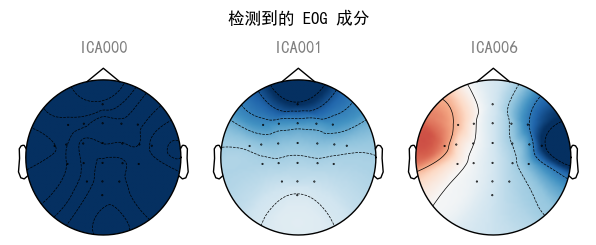

f:\Graduation Design\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


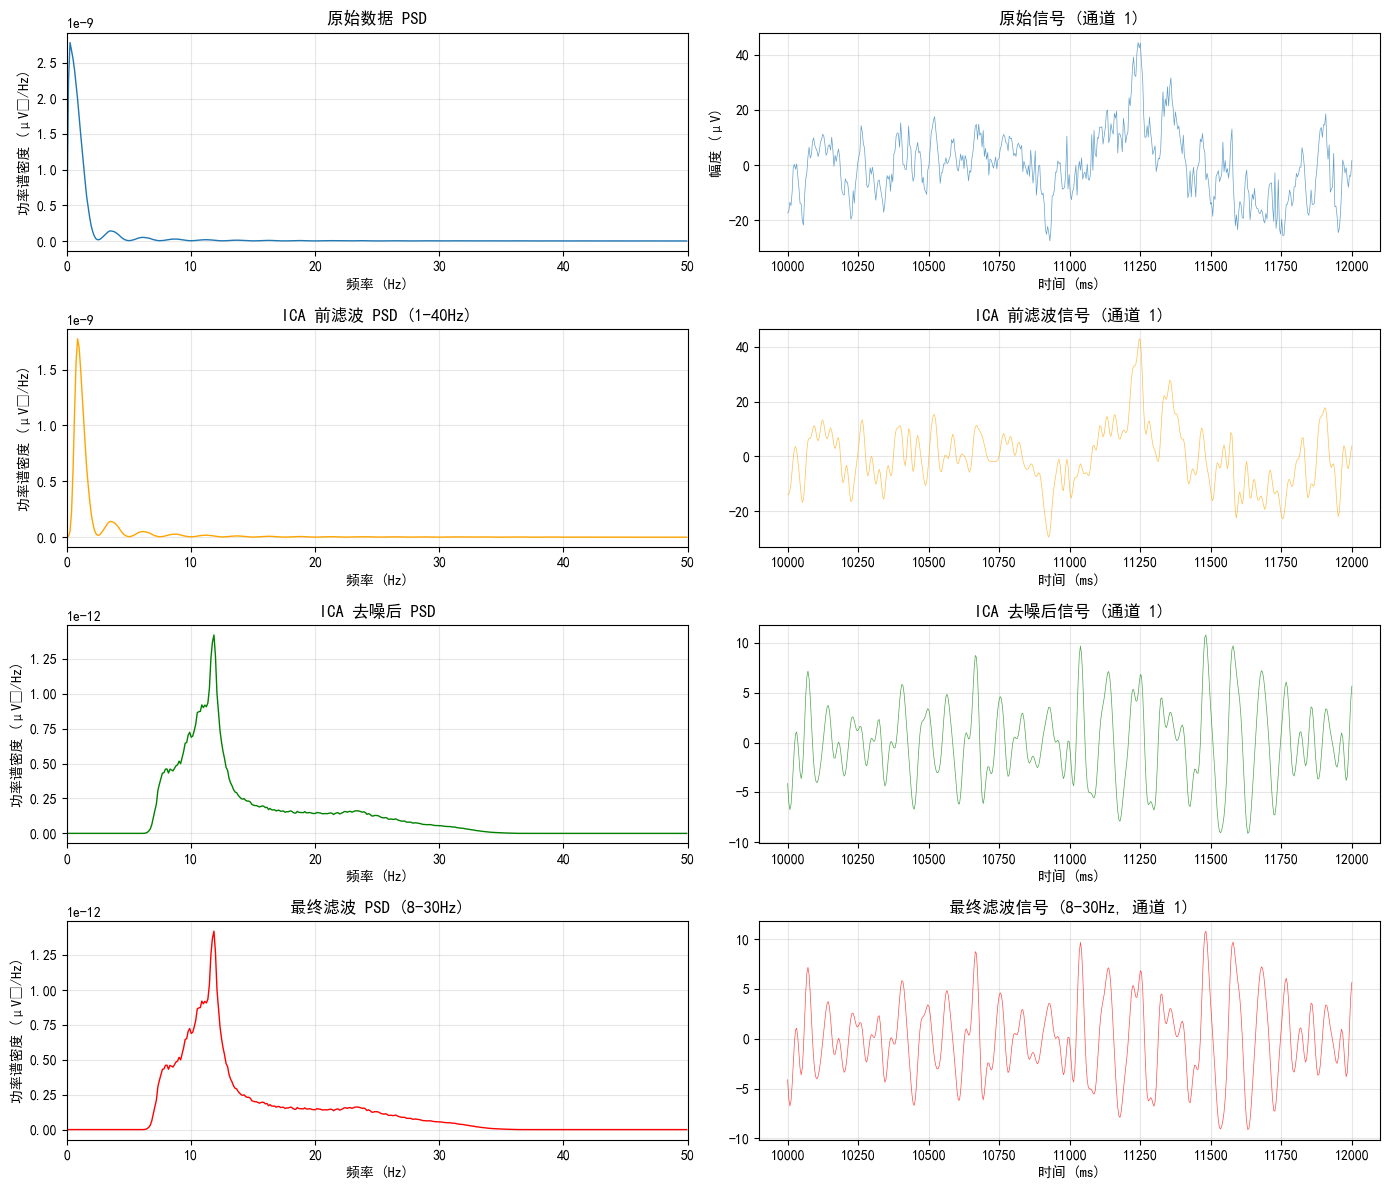

In [7]:
# 运行完整预处理流程
print(f"开始预处理被试 {subject_id}...")
epochs, ica_model = complete_preprocessing_pipeline(subject=subject_id)

print(f"\n✅ 预处理完成")
print(f"   - Epochs 数量: {len(epochs)}")
print(f"   - 通道数: {len(epochs.ch_names)}")
print(f"   - 时间点数: {epochs.get_data().shape[2]}")
print(f"   - 时间窗口: [{epochs.tmin}, {epochs.tmax}] s")

In [ ]:
# 检查 epochs 的详细信息
print("Epochs 详细信息:")
print(f"   - 数据类型: {type(epochs)}")
print(f"   - 数据形状: {epochs.get_data().shape}")
print(f"   - 事件数组形状: {epochs.events.shape}")
print(f"   - 事件 ID: {epochs.event_id}")

# 查看事件分布
print("\n事件分布:")
for event_name, event_id in epochs.event_id.items():
    mask = epochs.events[:, 2] == event_id
    count = np.sum(mask)
    print(f"   - {event_name} (ID={event_id}): {count} 个 trials")

In [ ]:
# 提取标签
labels = epochs.events[:, 2]
unique_labels, label_counts = np.unique(labels, return_counts=True)

print("标签信息:")
print(f"   - 唯一标签: {unique_labels}")
print(f"   - 标签数量: {label_counts}")
print(f"   - 总样本数: {len(labels)}")

# 映射标签到类别名称
label_to_name = {v: k for k, v in epochs.event_id.items()}
print("\n标签映射:")
for label in unique_labels:
    name = label_to_name.get(label, '未知')
    count = np.sum(labels == label)
    print(f"   - {label} -> {name}: {count} 个样本")

## 4. 特征提取检查

In [ ]:
# 提取 CSP 特征
print("提取 CSP 特征...")
X_csp, csp_model = extract_csp_features(epochs, n_components=4)

print(f"\nCSP 特征信息:")
print(f"   - 特征矩阵形状: {X_csp.shape}")
print(f"   - 滤波器形状: {csp_model['filters'].shape}")
print(f"   - 模式形状: {csp_model['patterns'].shape}")
print(f"   - 特征值: {csp_model['eigenvalues']}")

In [ ]:
# 提取小波能量特征
print("提取小波能量特征...")
X_wavelet = extract_wavelet_energy_features(epochs, wavelet='db4', level=4)

print(f"\n小波特征信息:")
print(f"   - 特征矩阵形状: {X_wavelet.shape}")
print(f"   - 特征范围: [{X_wavelet.min():.4f}, {X_wavelet.max():.4f}]")
print(f"   - 特征均值: {X_wavelet.mean():.4f}")
print(f"   - 特征标准差: {X_wavelet.std():.4f}")

In [ ]:
# 特征统计分析
print("特征统计对比:")
print(f"\nCSP 特征:")
print(f"   - 形状: {X_csp.shape}")
print(f"   - 均值: {X_csp.mean(axis=0)}")
print(f"   - 标准差: {X_csp.std(axis=0)}")
print(f"   - 最小值: {X_csp.min(axis=0)}")
print(f"   - 最大值: {X_csp.max(axis=0)}")

print(f"\n小波特征:")
print(f"   - 形状: {X_wavelet.shape}")
print(f"   - 均值: {X_wavelet.mean(axis=0)}")
print(f"   - 标准差: {X_wavelet.std(axis=0)}")
print(f"   - 最小值: {X_wavelet.min(axis=0)}")
print(f"   - 最大值: {X_wavelet.max(axis=0)}")

## 5. 分类器训练和评估

In [ ]:
# 使用 CSP 特征训练 SVM
print("使用 CSP 特征训练 SVM 分类器...")
clf_csp, cv_scores_csp, acc_csp = train_svm_classifier(X_csp, labels, cv_folds=10)

print(f"\n✅ CSP 特征分类结果:")
print(f"   - 交叉验证准确率: {acc_csp:.4f} ± {cv_scores_csp.std():.4f}")

In [ ]:
# 使用小波特征训练 SVM
print("使用小波特征训练 SVM 分类器...")
clf_wavelet, cv_scores_wavelet, acc_wavelet = train_svm_classifier(X_wavelet, labels, cv_folds=10)

print(f"\n✅ 小波特征分类结果:")
print(f"   - 交叉验证准确率: {acc_wavelet:.4f} ± {cv_scores_wavelet.std():.4f}")

In [ ]:
# 对比两种特征的性能
print("特征性能对比:")
print(f"   - CSP 特征准确率: {acc_csp:.4f} ± {cv_scores_csp.std():.4f}")
print(f"   - 小波特征准确率: {acc_wavelet:.4f} ± {cv_scores_wavelet.std():.4f}")

if acc_csp > acc_wavelet:
    print(f"\n🏆 CSP 特征表现更好，提升: {(acc_csp - acc_wavelet)*100:.2f}%")
else:
    print(f"\n🏆 小波特征表现更好，提升: {(acc_wavelet - acc_csp)*100:.2f}%")

## 6. 数据可视化调试

In [ ]:
# 可视化原始数据片段
fig = raw.plot(duration=5, start=10, show=False, title=f'原始数据 - {subject_id}')
plt.tight_layout()
plt.savefig('./output_img/debug_raw_data.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ 原始数据图已保存到 ./output_img/debug_raw_data.png")

In [ ]:
# 可视化平均诱发电位
fig = epochs.plot_average(show=False, title=f'平均诱发电位 - {subject_id}')
plt.tight_layout()
plt.savefig('./output_img/debug_epochs_average.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ 平均诱发电位图已保存到 ./output_img/debug_epochs_average.png")

In [ ]:
# 可视化功率谱密度
psd = epochs.compute_psd(method='welch', fmin=1, fmax=50)
fig = psd.plot(show=False, title=f'功率谱密度 - {subject_id}')
plt.tight_layout()
plt.savefig('./output_img/debug_psd.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ 功率谱密度图已保存到 ./output_img/debug_psd.png")

## 7. 数据导出和保存

In [ ]:
# 保存调试信息到文件
import pickle

debug_info = {
    'subject_id': subject_id,
    'raw_info': {
        'sfreq': raw.info['sfreq'],
        'n_channels': len(raw.ch_names),
        'duration': raw.times[-1],
        'n_times': raw.n_times,
    },
    'epochs_info': {
        'n_epochs': len(epochs),
        'n_channels': len(epochs.ch_names),
        'n_times': epochs.get_data().shape[2],
        'tmin': epochs.tmin,
        'tmax': epochs.tmax,
    },
    'labels': {
        'unique_labels': unique_labels.tolist(),
        'label_counts': label_counts.tolist(),
        'label_to_name': label_to_name,
    },
    'features': {
        'csp_shape': X_csp.shape,
        'wavelet_shape': X_wavelet.shape,
    },
    'classification': {
        'csp_accuracy': float(acc_csp),
        'wavelet_accuracy': float(acc_wavelet),
    }
}

# 保存调试信息
output_path = f'./output_img/debug_info_{subject_id}.pkl'
with open(output_path, 'wb') as f:
    pickle.dump(debug_info, f)

print(f"✅ 调试信息已保存到: {output_path}")
print("\n调试信息内容:")
for key, value in debug_info.items():
    print(f"   - {key}: {value}")

## 8. 快速检查函数

In [ ]:
def quick_data_check(subject_id='A01T'):
    """
    快速检查数据的基本信息
    
    Args:
        subject_id: 被试 ID
    """
    print(f"\n{'='*60}")
    print(f"快速数据检查 - {subject_id}")
    print(f"{'='*60}")
    
    # 加载数据
    raw = get_modified_raw_data(subject=subject_id)
    epochs, _ = complete_preprocessing_pipeline(subject=subject_id)
    
    # 基本信息
    print(f"\n📊 基本信息:")
    print(f"   - 采样率: {raw.info['sfreq']} Hz")
    print(f"   - 通道数: {len(raw.ch_names)}")
    print(f"   - Epochs 数: {len(epochs)}")
    
    # 标签信息
    labels = epochs.events[:, 2]
    unique_labels, label_counts = np.unique(labels, return_counts=True)
    print(f"\n🏷️  标签信息:")
    print(f"   - 唯一标签: {unique_labels}")
    print(f"   - 标签分布: {label_counts}")
    
    # 特征信息
    X_csp, _ = extract_csp_features(epochs, n_components=4)
    X_wavelet = extract_wavelet_energy_features(epochs, wavelet='db4', level=4)
    print(f"\n🔧 特征信息:")
    print(f"   - CSP 特征形状: {X_csp.shape}")
    print(f"   - 小波特征形状: {X_wavelet.shape}")
    
    # 分类性能
    _, _, acc_csp = train_svm_classifier(X_csp, labels, cv_folds=5)
    _, _, acc_wavelet = train_svm_classifier(X_wavelet, labels, cv_folds=5)
    print(f"\n📈 分类性能 (5折CV):")
    print(f"   - CSP 准确率: {acc_csp:.4f}")
    print(f"   - 小波准确率: {acc_wavelet:.4f}")
    
    print(f"\n{'='*60}")
    print("✅ 快速检查完成")
    print(f"{'='*60}\n")

# 使用示例
# quick_data_check('A01T')
# quick_data_check('A02T')

## 9. 常见问题排查

In [ ]:
def check_data_quality(epochs):
    """
    检查数据质量
    
    Args:
        epochs: Epochs 对象
    """
    print("\n🔍 数据质量检查:")
    
    data = epochs.get_data()
    
    # 检查 NaN 值
    nan_count = np.isnan(data).sum()
    print(f"   - NaN 值数量: {nan_count}")
    
    # 检查 Inf 值
    inf_count = np.isinf(data).sum()
    print(f"   - Inf 值数量: {inf_count}")
    
    # 检查数据范围
    print(f"   - 数据范围: [{data.min():.6f}, {data.max():.6f}]")
    
    # 检查每个通道的标准差
    channel_stds = data.std(axis=(0, 2))  # 对 trials 和时间轴求标准差
    print(f"   - 通道标准差范围: [{channel_stds.min():.6f}, {channel_stds.max():.6f}]")
    
    # 检查是否有异常通道
    mean_std = channel_stds.mean()
    std_threshold = mean_std * 3
    abnormal_channels = channel_stds > std_threshold
    if abnormal_channels.any():
        print(f"   ⚠️  发现 {abnormal_channels.sum()} 个异常通道:")
        for i, is_abnormal in enumerate(abnormal_channels):
            if is_abnormal:
                print(f"      - {epochs.ch_names[i]}: std={channel_stds[i]:.6f}")
    else:
        print(f"   ✅ 未发现异常通道")

# 使用示例
# check_data_quality(epochs)

## 使用说明

1. **修改被试 ID**: 在第二个代码块中修改 `subject_id` 变量
2. **运行单元格**: 按顺序运行各个单元格查看不同信息
3. **快速检查**: 使用 `quick_data_check()` 函数快速获取数据概览
4. **数据质量**: 使用 `check_data_quality()` 函数检查数据质量问题
5. **保存图片**: 所有调试图片都会保存到 `./output_img/` 文件夹

### 常用调试场景:
- 查看标签分布: 运行第 2 节的 cells
- 检查特征形状: 运行第 4 节的 cells
- 对比分类性能: 运行第 5 节的 cells
- 可视化数据: 运行第 6 节的 cells